In [1]:
import tigramite
from tigramite import plotting as tp
from tigramite.pcmci import PCMCI
from tigramite import data_processing as pp
from tigramite.independence_tests.parcorr import ParCorr

# ------------
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# --- Getting dataset
dataset = pd.read_csv('delay_new_.csv', encoding='utf-8')
features = ["Konin", "Poznan", "Kutno"]
dataset = dataset[features]
dataset = dataset.astype(np.float64)
print(dataset)

     Konin  Poznan  Kutno
0     10.0    16.0    0.0
1     10.0    16.0    0.0
2     10.0    16.0    0.0
3     11.0    17.0    0.0
4     11.0    17.0    0.0
..     ...     ...    ...
571    1.0     2.0    1.0
572    1.0     2.0    1.0
573    1.0     2.0    1.0
574    1.0     2.0    1.0
575    5.0     7.0    4.0

[576 rows x 3 columns]


In [3]:
var_names = [r'$Konin$', r'$Poznan$', r'$Kutno$']
dataframe = pp.DataFrame(dataset.values, 
                         datatime = {0:np.arange(len(dataset))}, 
                         var_names=var_names)

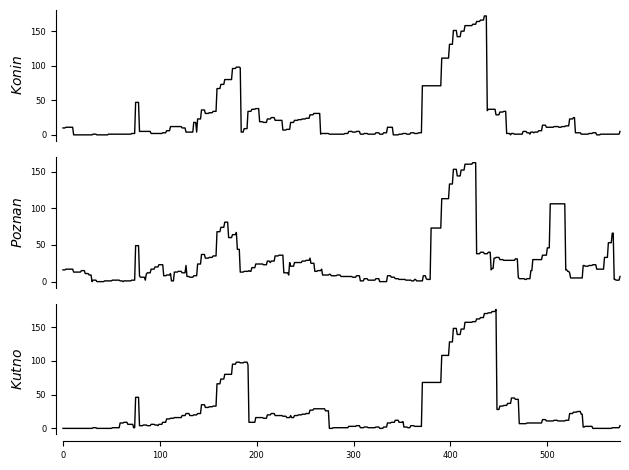

In [4]:
tp.plot_timeseries(dataframe); plt.show()

In [5]:
parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(
    dataframe=dataframe, 
    cond_ind_test=parcorr,
    verbosity=1)
correlations = pcmci.get_lagged_dependencies(tau_max=12, val_only=True)['val_matrix']


##
## Estimating lagged dependencies 
##

Parameters:

independence test = par_corr
tau_min = 0
tau_max = 12


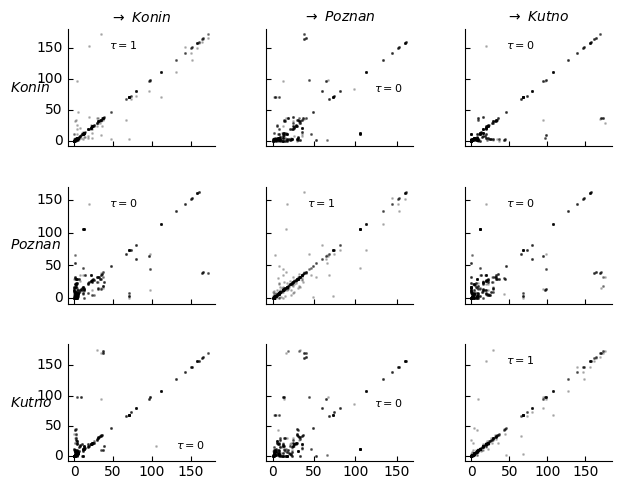

In [6]:
matrix_lags = None #np.argmax(np.abs(correlations), axis=2)
tp.plot_scatterplots(dataframe=dataframe, add_scatterplot_args={'matrix_lags':matrix_lags}); plt.show()

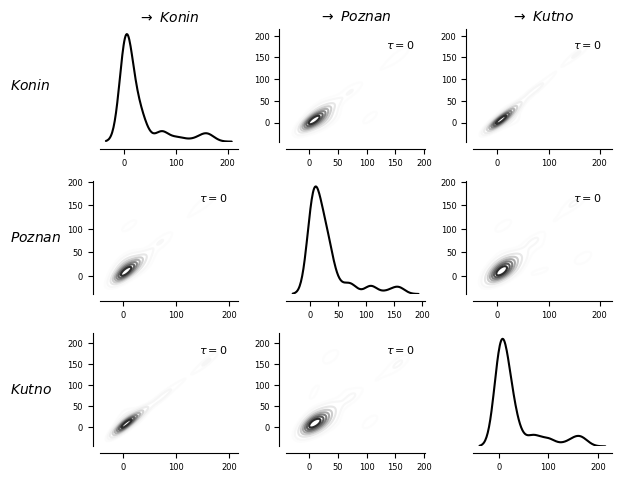

In [7]:
tp.plot_densityplots(dataframe=dataframe, add_densityplot_args={'matrix_lags':matrix_lags})
plt.show()

In [8]:
parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(
    dataframe=dataframe, 
    cond_ind_test=parcorr,
    verbosity=1)


##
## Estimating lagged dependencies 
##

Parameters:

independence test = par_corr
tau_min = 0
tau_max = 12


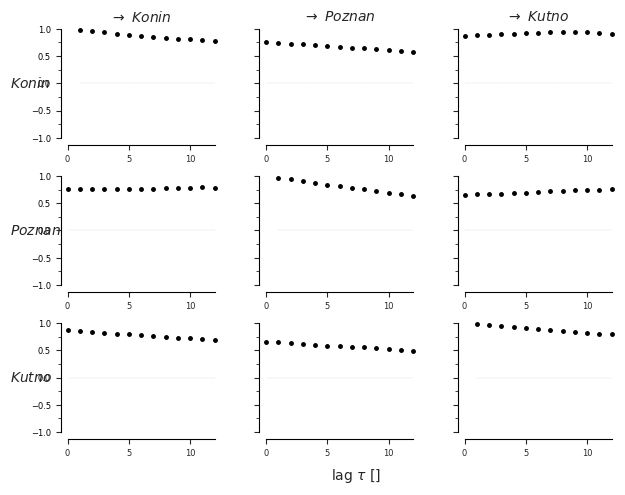

In [9]:
correlations = pcmci.get_lagged_dependencies(tau_max=12, val_only=True)['val_matrix']
lag_func_matrix = tp.plot_lagfuncs(val_matrix=correlations, setup_args={'var_names':var_names, 
                                    'x_base':5, 'y_base':.5}); plt.show()

In [10]:
pcmci.verbosity = 1
results = pcmci.run_pcmci(tau_max=12, pc_alpha=None, alpha_level=0.01)


##
## Step 1: PC1 algorithm for selecting lagged conditions
##

Parameters:
independence test = par_corr
tau_min = 1
tau_max = 12
pc_alpha = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
max_conds_dim = None
max_combinations = 1



## Resulting lagged parent (super)sets:

    Variable $Konin$ has 4 link(s):
    [pc_alpha = 0.4]
        ($Konin$ -1): max_pval = 0.00000, |min_val| =  0.699
        ($Poznan$ -1): max_pval = 0.04141, |min_val| =  0.087
        ($Poznan$ -10): max_pval = 0.25376, |min_val| =  0.049
        ($Poznan$ -2): max_pval = 0.30685, |min_val| =  0.044

    Variable $Poznan$ has 3 link(s):
    [pc_alpha = 0.2]
        ($Poznan$ -1): max_pval = 0.00000, |min_val| =  0.699
        ($Konin$ -1): max_pval = 0.12223, |min_val| =  0.066
        ($Poznan$ -12): max_pval = 0.14057, |min_val| =  0.063

    Variable $Kutno$ has 5 link(s):
    [pc_alpha = 0.5]
        ($Kutno$ -1): max_pval = 0.00000, |min_val| =  0.703
        ($Konin$ -8): max_pval = 0.00026, |min_val| =  0.155
        ($

In [11]:
q_matrix = pcmci.get_corrected_pvalues(p_matrix=results['p_matrix'], tau_max=12, fdr_method='fdr_bh')
pcmci.print_significant_links(
        p_matrix = q_matrix,
        val_matrix = results['val_matrix'],
        alpha_level = 0.01)
graph = pcmci.get_graph_from_pmatrix(p_matrix=q_matrix, alpha_level=0.01, 
            tau_min=0, tau_max=12, link_assumptions=None)
results['graph'] = graph


## Significant links at alpha = 0.01:

    Variable $Konin$ has 5 link(s):
        ($Konin$ -1): pval = 0.00000 | val =  0.671
        ($Kutno$  0): pval = 0.00000 | val =  0.337
        ($Poznan$ -11): pval = 0.00000 | val =  0.265
        ($Poznan$  0): pval = 0.00002 | val =  0.180
        ($Poznan$ -12): pval = 0.00683 | val = -0.148

    Variable $Poznan$ has 3 link(s):
        ($Poznan$ -1): pval = 0.00000 | val =  0.684
        ($Konin$  0): pval = 0.00002 | val =  0.180
        ($Kutno$  0): pval = 0.00010 | val =  0.166

    Variable $Kutno$ has 7 link(s):
        ($Kutno$ -1): pval = 0.00000 | val =  0.662
        ($Konin$ -10): pval = 0.00000 | val =  0.349
        ($Konin$  0): pval = 0.00000 | val =  0.337
        ($Konin$ -11): pval = 0.00000 | val = -0.283
        ($Konin$ -8): pval = 0.00000 | val =  0.236
        ($Poznan$  0): pval = 0.00010 | val =  0.166
        ($Kutno$ -10): pval = 0.00729 | val = -0.147


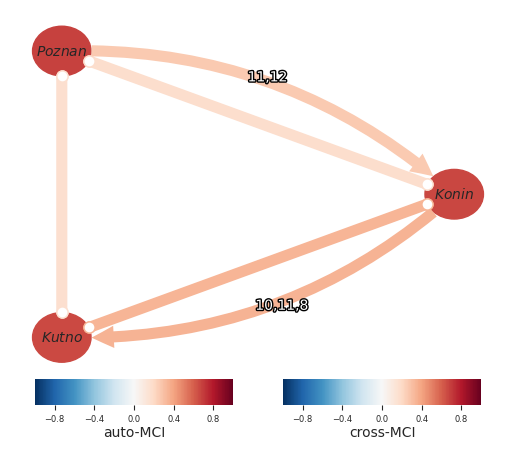

In [12]:
tp.plot_graph(
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=var_names,
    link_colorbar_label='cross-MCI',
    node_colorbar_label='auto-MCI',
    show_autodependency_lags=False
    ); plt.show()

## 

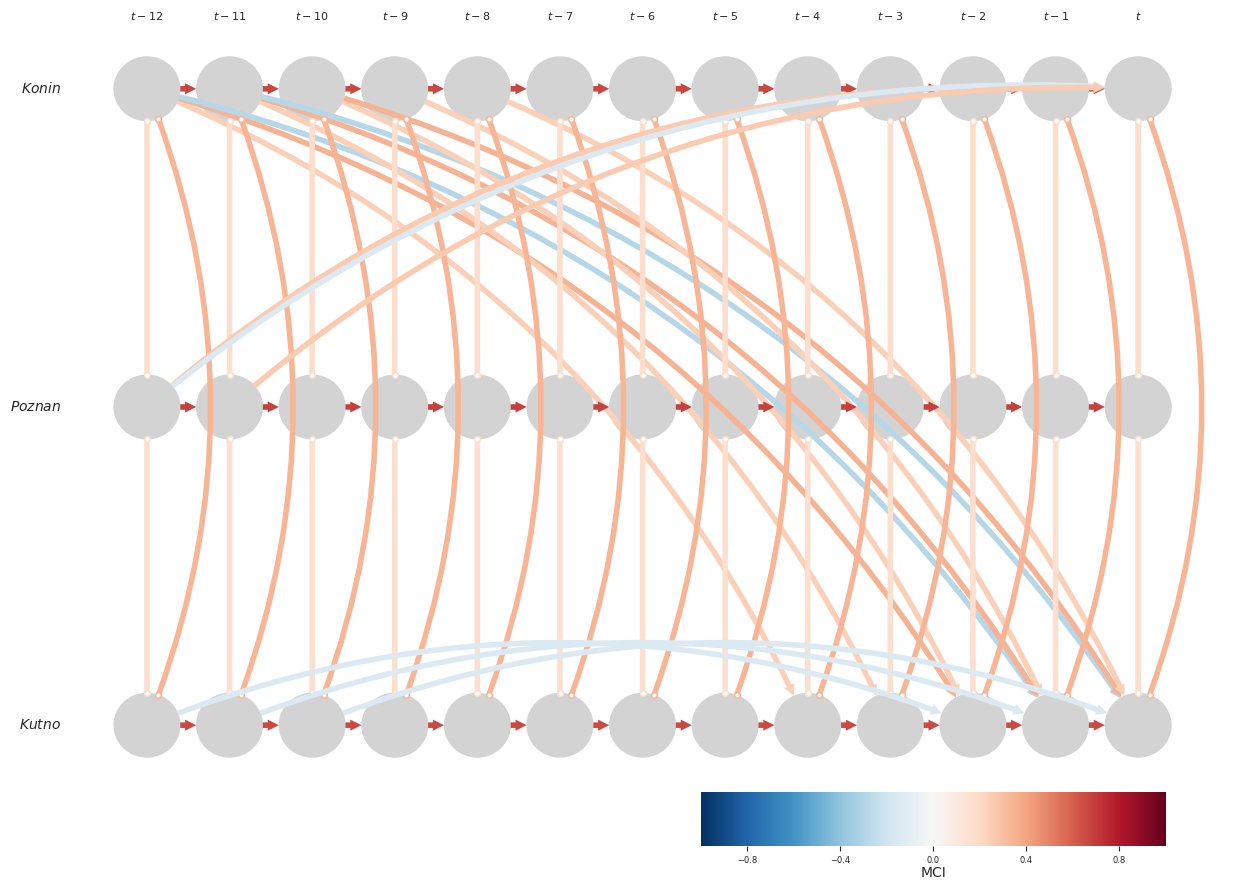

In [13]:


# Plot time series graph    
tp.plot_time_series_graph(
    figsize=(15,10),
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=var_names,
    link_colorbar_label='MCI',
    ); plt.show()